# Practica para flujo de fluidos incompresibles

In [1]:
import numpy as np

## Ecuación de Shacham para el calculo del factor de Darcy de flujo en tuberías:

$$
f_D = \left[-2 \log\left(\frac{\frac{\epsilon}{D}}{3.71}-\frac{5.02}{\mathrm{Re}}\log\left(\frac{\frac{\epsilon}{D}}{3.71}+\frac{14.5}{\mathrm{Re}}\right)\right)\right]^{-2}
$$

## Método de las 2k de Hooper para calcular K de accesorio

$$
K = \frac{K_1}{Re} + K_{\infty} (1 + \frac{1}{D_i})
$$

In [2]:
def calculo_Fd(rugosidad, D_interno, Reynolds):
    proporcion = rugosidad / D_interno
    
    A = ((proporcion/3.71)+(14.5/Reynolds))
    B = (5.02/Reynolds) * np.log10(A)
    C = (proporcion/3.71) - B
    D = -2 * np.log10(C)
    Fd = D**(-2)
    
    return Fd


def calculo_k_2k(D_interno, Reynolds, k1, kinf):
    D_interno = D_interno * 39.3701
    A = 1 + (1/D_interno)
    B = kinf * A
    K = (k1/Reynolds) + B
    
    return K    

### 1) Considere el punto 1 de una tubería donde la presión absoluta es de 5 atm, ubicado a 250 m de un punto 2 de la misma tubería donde la presión absoluta es de 3 atm. Si no existen diferencias sustanciales en las alturas entre estos dos puntos para el glicerol ($\rho_{glicerol} = 1260$ kg/m³ aprox).

### Responda brevemente.¿Cuánto son las pérdidas totales en este tramo de tubería si el fluido fluye del punto 1 al punto 2? (No hay cambio de fase, y es fludo newtoniano)

Suposiciones:

- No hay cambio de energía potencial.
- No hay cambio de energía cinética, ya que en el tramo no hay cambio de area, no indican fluido que acelera.
- El fluido es incompresible, no hay cambio significativo de densidad en el glicerol.
- No hay Potencia de impulso, por lo tanto el termino $\dot{W} = 0$

In [3]:
P_1 = 5
P_2 = 3
delta_P = - (P_2 - P_1)         # atm
delta_P = delta_P * (101325)    # Pa
den = 1260                      # kg/m³
print(f'Cambio de presión : {delta_P} Pa')

perdidas_flujo = (delta_P/den) * 2

print(f'Perdidas de energía por flujo : {perdidas_flujo:,.4f} J / Kg')
print(f'Perdidas de energía por flujo : {perdidas_flujo/1000:,.4f} kJ / Kg')

Cambio de presión : 202650 Pa
Perdidas de energía por flujo : 321.6667 J / Kg
Perdidas de energía por flujo : 0.3217 kJ / Kg


### 2) En una unidad de la planta de producción de ácido fumárico se necesita reparar la tubería de acero inoxidable 316 que conduce la solución acuosa de ácido maléico desde el tanque de preparación de la solución hasta el reactor de isomerización por un tramo de 20 metros en total. Como ingeniero de planta se le pide elegir el tipo de material adecuado para hacer la reparación entre los disponibles en el proveedor de confianza presentes en la siguiente tabla. Justifique con al menos dos motivos.


| Material             | Diametro         | Longitud  | Peso        | Rugosidad  | Precio              |
| -------------------- | ---------------- | --------- | ----------- | ---------- | ------------------- |
| PVC                  | 21mm             | 6m/tubo   | 1kg/tubo    | 1.5 micron | $ 30.000 COP / tubo |
| Polietileno          | 25mm             | 25m/rollo | 5.75kg/tubo | NA         | $ 80.000 COP/ rollo |
| Acero Inoxidable 316 | DN 1 inch sch 40 | 6m/tubo   | NA          | 45 micron  | 240 USD / tubo      |
| Vidrio               | 8mm              | 2m/tubo   | NA          | 1.5 micron | 300 USD / tubo      |


si 1 USD = 3500 COP (2026/04)

240USD = 840.000 COP
300USD = 1.050.000 COP

### Aspectos a analizar:

- El acido maleico tiende a tener a un valor muy bajo el pH en solución acuosa (pKa1 aprox 1.9), este aspecto se debe tener presente ya que puede causar daños al estar en contacto con distintos materiales
- El ácido maléico a condiciones ambientales se encuentra en estado sólido, por lo tanto se requiere precalentar para solubilizar en agua en temperaturas alrededor de 135°C
- Seguridad industrial: se asume el transito de alta frecuencia de operarios, espacios disponibles para evaluación de desempeño o reparación de segmentos entre equipos de proceso.
- Tiempo de vida util: se debe evaluar con que frecuencia se debe hacer cambio de tuberías por desgaste de herramientas para el flujo. 

### Elementos decisivos

- Se descartan las opciones de PVC y Polietileno, ya que estos funcionan bien para el flujo de fluidos con pH aproximadamente en 7 y a condiciones ambientales (como el agua), porque tienen menor temperatura máxima de servicio, mayor coeficiente de expansión térmica, reducción de módulo mecánico con temperatura aumentando tambien el riesgo de fugas

- Se descarta la opción material de vidrio por que presenta mayor costo en instalación y mantenimiento del material, en logística y manipulación. Poseen baja fragilidad mecánica, es decir baja tenacidad a la fractura, sensible a impactos y vibraciones y fallo súbito (sin daño gradua que permita dar indicios para mantenimiento preventivo), tambien es sensible a realizar adecuaciónes (como incorporar uniones tipo rosca, accesorios, T's)

### Acero Inoxidable 316 :

- Tiene mayor resistencia mecánica, resistiendo altos niveles de T y P, resistencia química para permitir el flujo de fluidos con pH acidos o básicos, sin presentar deformación química, y la frecuencia del mantenimiento es bajo y práctico. Su precio en un inicio puede ser elevado, pero los gastos extraordinarios para reparación, mantenimiento, reposición y adecuación, es bajo frente a las otras opciones, que quizas requieran mayor frecuencia de reposición de materiales que ya alcanzaron la vida util, y la reinstalación es otro gasto considerable.

### 3) Se necesita el siguiente montaje entre la descarga de la bomba que lleva el producto de fermentación desde un bioreactor a través de un filtro para separar la solución de etanol de las levaduras.

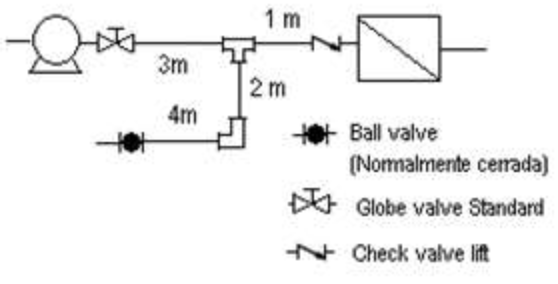

### Se desea garantizar una producción de:
### - 3.15 l/s de solución de etanol (caudal de diseño).
### - (viscosidad cinematica $\nu$ = 1 x 10^-5 m2/s) 

##### 1. Calcule las pérdidas locales y por fricción (longitud) si se sabe que la tubería es de acero inoxidable 316 DN 1 in Sch 40 (rugosidad 45 micron) con accesorios roscados. 
##### 2. Calcule las pérdidas en el filtro si se sabe que es de tipo superficial de 2.5 m2 y que opera a presión constante. Gracias a datos experimentales se sabe que el parámetro de formación de la torta uW/2k es igual a 1 atm*h/m2. 
##### 3. Si la energía entregada por la bomba es de 80 mca, es posible garantizar que sale filtrado a la salida del filtro?

Del catálogo del autor Darby, tomamos la siguiente referencia (acero inoxidable 316 DN 1 in Sch 40)

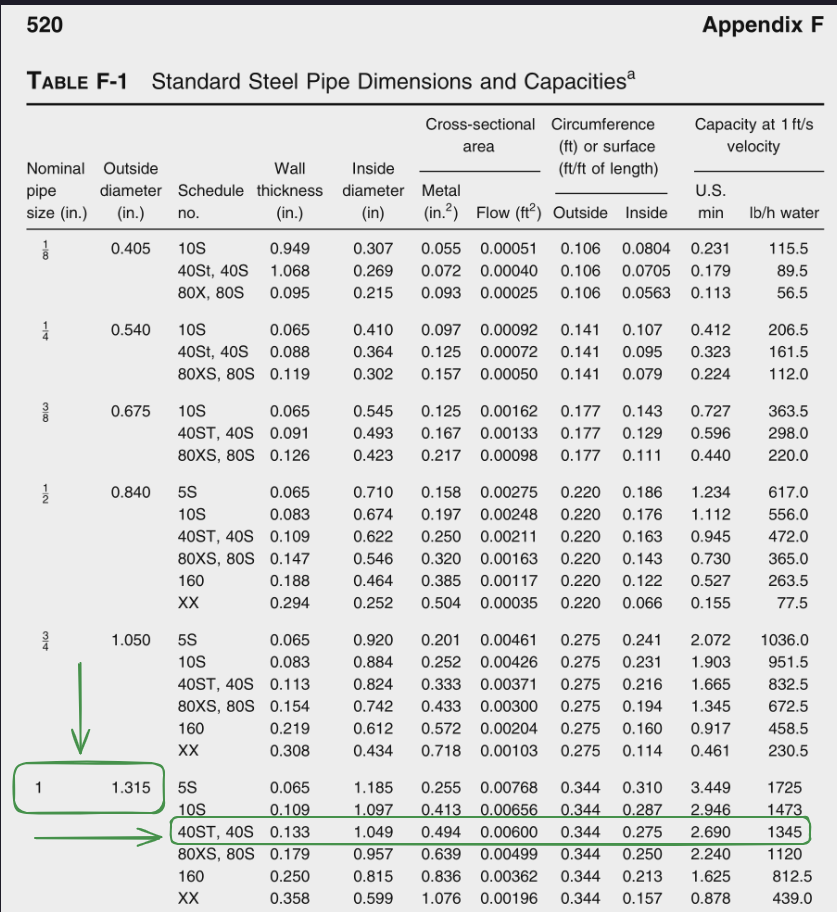

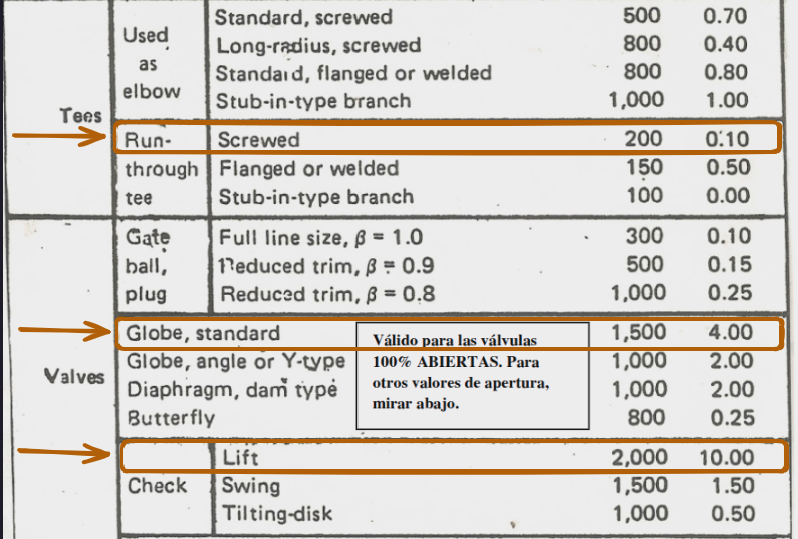

In [4]:
# Unidades:

g = 9.8                 # gravedad m / s²
visc_cinem = 1e-05      # viscosidad cinematica m² / s
caudal = 3.15 * (1/1000) # caudal m³ / s

#   Detalles tubería:
D_interno = 1.049 * (0.0254)        # diametro interno m
rugosidad = 45 * 1e-06              # rugodsidad m

#   Calculos :

A_flujo = np.pi * ((D_interno**2)/4)
vel_flujo = caudal / A_flujo

print(f'Area de flujo : {A_flujo:,.4f} m²')
print(f'velocidad de flujo : {vel_flujo:,.4f} m/s')



#   Objetivo 1 : Determinar reynolds para conocer el régimen de flujo:
#   ------------------------------------------------------------------

Reynolds = vel_flujo * D_interno / visc_cinem

print(f'\nNúmero de Reynolds para este régimen : {Reynolds:,.4f} ({Reynolds:,.2e})')
print(f'Al ser mayor a 4000 (Re > 4000), el flujo es turbulento')



#   Objetivo 2  : Perdidas de flujo desde la bomba, punto de descarga, hasta el friltro, se ignora el tramo a partir de la T hasta la valvula de descarga:
#   bomba_descarga ; valv_globo_standard ; L_3m ; T_ ; L_1m ; valv_check
#   ------------------------------------------------------------------------------------------------------------------------------------------------------

#   Sección solo tuberías (L_3m, L_1m):
#   el factor de darcy solo es funcion de propiedades de flujo y area de flujo de tubería.

fd_AI_DN1_SCH40 = calculo_Fd(rugosidad, D_interno, Reynolds)

h_L_3m = (3/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40
h_L_1m = (1/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40

#   Sección accesorios y valvulas (bomba_descarga ; valv_globo_standard ; T_ ; valv_check):
#   Para efectos prácticos, se usara el método de las 2k

k1_valv_globo_standard = 1500 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_globo_standard = 4  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_globo_standard = calculo_k_2k(D_interno, Reynolds, k1_valv_globo_standard, kinf_valv_globo_standard)

k1_T_ = 200 # Tomado del catálogo de la asignatura (OPTCM) tipo rosca
kinf_T_ = 0.1  # Tomado del catálogo de la asignatura (OPTCM) tipo rosca
K_T_ = calculo_k_2k(D_interno, Reynolds, k1_T_, kinf_T_)

k1_valv_check_lift = 2000 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_check_lift = 10  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_check_lift = calculo_k_2k(D_interno, Reynolds, k1_valv_check_lift, kinf_valv_check_lift)

h_valv_globo_standard = K_valv_globo_standard * ((vel_flujo**2)/2)
h_T_ = K_T_ * ((vel_flujo**2)/2)
h_valv_check_lift = K_valv_check_lift * ((vel_flujo**2)/2)

#   Calculamos h_total:

h_total = h_L_3m + h_L_1m + h_valv_globo_standard + h_T_ + h_valv_check_lift

print(f'perdidas locales total : {h_total:,.4f} J/kg')
print(f'perdidas locales total : {h_total/1000:,.2f} kJ/kg')


#   Objetivo 3 : Perdidas en el filtro
'''
Asumimos que la resistencia del medio filtrante es mínima, por tanto, a = 0
y C_2 = 0, y el valor del líquido filtrado es Q*t

usamos la siguiente expresión:

-Delta_P * t = C_1 * (Q*t/A)^2 
'''
#   ------------------------------------------------------------------------------------------------------------------------------------------------------
area_filtro = 2.5       # m²
uW_2k = 1               # atm.h/m²
uW_2k = uW_2k * (101325) * (3600)   # Pa.s/m²
C_1 = uW_2k

'''
Tenemos la siguiente expresión:

delta_P_filtro = C_1 * ((caudal)/area_filtro)**2 * t

en este caso, el valor de t ya esta implicito en C_1, ya que C_1 es un parametro global que ya incluye en tiempo para análisis experimentales
por tanto
'''

delta_P_filtro = C_1 * ((caudal)/area_filtro)**2 
print(f'cambio de presión en el filtro : {delta_P_filtro:,.4f} Pa')
den_etanol = 789    # kg/m³

h_filtro = delta_P_filtro / den_etanol

print(f'perdida de energía en el filtro : {h_filtro:,.4f} J/kg')
print(f'Perdidas locales total con filtro incluido : {h_total + h_filtro:,.4f} J/kg')


#   Objetivo 4 : Garantizar el flujo
'''
    Aplicamos principio de Bernoulli para verificar si llega al tanque despues del filtro
    Solo queremos garantizar si puede vencer todas las perdidas de energía por flujo
    Potencia bomba > perdidas de energía por flujo
'''
#   ------------------------------------------------------------------------------------------------------------------------------------------------------
potencia_bomba = 8      # mca (metros columna agua)
potencia_bomba = g * potencia_bomba # J/kg
print(f'Potencia de bomba en unidades de energía: {potencia_bomba:,.4f} J/kg')
if potencia_bomba > (h_total+h_filtro):
    print(f"La bomba si suministra la potencia necesaria de flujo {potencia_bomba:,.2f} > {h_total+h_filtro:,.2f}")
else:
    print(f"La bomba No suministra la potencia necesaria de flujo ({potencia_bomba:,.2f} < {h_total+h_filtro:,.2f})")
    h_total_filtro = h_total+h_filtro
    potencia_minima_bomba = h_total_filtro / g
    print(f'lo mínimo necesario en la bomba sería {potencia_minima_bomba:,.2f} mca')

Area de flujo : 0.0006 m²
velocidad de flujo : 5.6494 m/s

Número de Reynolds para este régimen : 15,052.5981 (1.51e+04)
Al ser mayor a 4000 (Re > 4000), el flujo es turbulento
perdidas locales total : 517.0402 J/kg
perdidas locales total : 0.52 kJ/kg
cambio de presión en el filtro : 579.1089 Pa
perdida de energía en el filtro : 0.7340 J/kg
Perdidas locales total con filtro incluido : 517.7742 J/kg
Potencia de bomba en unidades de energía: 78.4000 J/kg
La bomba No suministra la potencia necesaria de flujo (78.40 < 517.77)
lo mínimo necesario en la bomba sería 52.83 mca


### 4) ¿Cuál es la condición necesaria para que exista flujo de fluido en una tubería?

Se requiere de gradiente de energía mecánica entre dos puntos. Se debe de dar (al menos unon):
- diferencia de presión.
- diferencia de altura.
- diferencia de energía cinética.
- Inyección de potencia (por ejemplo, una bomba).

### 5) "Para un caudal dado, la caída de presión entre dos puntos de una tubería aumenta al aumentar el diámetro de esta” Que se puede concluir?:

Partimos de le expresión que permite calcular perdida de energía de flujo por fricción:

$$
\begin{aligned}
h_{f} = f_D \frac{L}{D} \frac{\vec{V}^2}{2} \\[10 pt]
Q = \vec{V}*A = \text{constante} \\[10 pt]
A = \pi \frac{D²}{4}
\end{aligned}
$$

El caudal no cambia, permanece constante, suponemos L conocido y la densidad del líquido conocido al igual que el factor de Darcy, por tanto con Bernoulli:

$$
\begin{aligned}
\frac{\Delta P}{\rho} = h_{f}\\[10 pt]
\frac{\Delta P}{\rho} = f_D \frac{L}{D} \frac{\vec{V}^2}{2}\\[10 pt]
\text{sea }C =  \frac{8\rho f_DLQ^2}{\pi^2}\\[10 pt]
\Delta P = C \frac{1}{D^5}\\[10 pt]
\end{aligned}
$$

Se realizo sustituciones entre las ecuaciones presentadas, y se llega a la relación de que la relación entre la caida de presión y el diametro de tubería es inversamente proporcional (mientras mas sube el diamentro, el valor de la caida de presión disminuye), por lo tanto, la observación "Para un caudal dado, la caída de presión entre dos puntos de una tubería aumenta al aumentar el diámetro de esta” es totalmente falso.

### 6) Se quiere instalar un filtro superficial de 3m² que opera a presión constante en una fábrica de jugos al final del proceso de producción de jugo de mora con el fin de remover las semillas. El jugo con semillas, sale de la licuadora industrial (blender) a una rata de 30l/h y una presión de 1.3bar. Actualmente se dispone del montaje mostrado en la figura para conectar la descarga de licuadora e instalar el filtro en la posición indicada. Se le pide comprobar si se puede realizar el transporte y filtración del jugo sin necesidad de aportes energéticos adicionales:

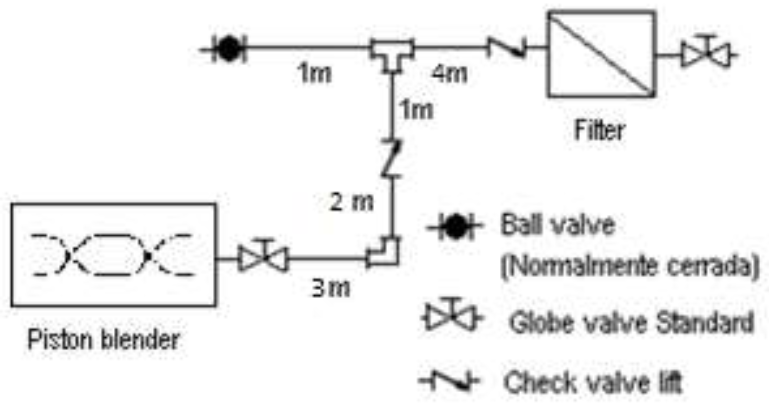

#### 1. Calcule las pérdidas en el filtro si, gracias a datos experimentales, se sabe que el parámetro de formación de la torta uW/2k es igual a 3 bar*h/m2 
#### 2. Calcule las pérdidas totales, (por accesorios, por fricción y por el filtro) en el montaje actual si se sabe que las tuberías son de acero inoxidable 316 DN 1 in Sch 40 (rugosidad 45 micron) con accesorios soldados. (viscosidad cinemática del jugo con semillas 1 x 10^-5 m2/s, densidad 950 Kg/m3) 
#### 3. ¿Se obtiene jugo en la válvula a la salida del filtro? En otras palabras, ¿La energía entregada por el blender es suficiente para vencer las pérdidas totales (incluida la filtración) y la presión atmosférica? En caso contrario, presente al menos una sugerencia para lograr la obtención del jugo filtrado.

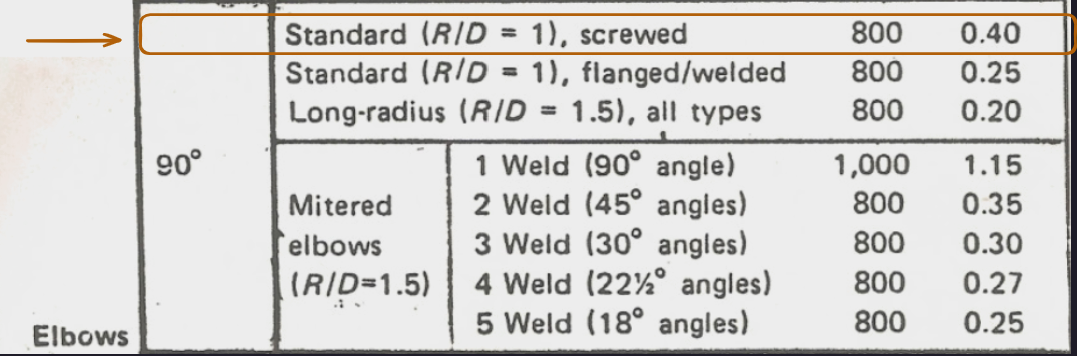

In [5]:
# Unidades:

g = 9.8                             # gravedad m / s²
visc_cinem = 1e-05                  # viscosidad cinematica m² / s

caudal = 30 * (1/1000) * (1/3600)   # caudal m³ / s
den_fluido = 950                    # kg / m³
P_out_blender = 1.3 * (100000)      # Pa

#   Detalles tubería:
D_interno = 1.049 * (0.0254)        # diametro interno m
rugosidad = 45 * 1e-06              # rugodsidad m

#   Calculos :

A_flujo = np.pi * ((D_interno**2)/4)    # esto es de tubería m²
vel_flujo = caudal / A_flujo

print(f'Area de flujo : {A_flujo:,.4f} m²')
print(f'velocidad de flujo : {vel_flujo:,.4f} m/s')


#   Objetivo 1 : Determinar reynolds para conocer el régimen de flujo:
#   ------------------------------------------------------------------

Reynolds = vel_flujo * D_interno / visc_cinem

print(f'\nNúmero de Reynolds para este régimen : {Reynolds:,.4f} ({Reynolds:,.2e})')
print(f'Al ser menor a 2400 (Re < 2400), el flujo es laminar\n')


#   Objetivo 2 : Perdidas en el filtro:
'''
    Asumimos que la resistencia del medio filtrante es mínima, por tanto, a = 0
    y C_2 = 0, y el valor del líquido filtrado es Q*t

    usamos la siguiente expresión:

    -Delta_P * t = C_1 * (Q*t/A)^2 
'''
#   ------------------------------------------------------------------
A_filtro = 3    # esto es de filtro m²
uW_2k = 3       
uW_2k = uW_2k * (100000) * (3600)   # se realiza la conversión a : Pa . s / m²
C_1 = uW_2k

'''
Tenemos la siguiente expresión:

delta_P_filtro = C_1 * ((caudal)/area_filtro)**2 * t

en este caso, el valor de t ya esta implicito en C_1, ya que C_1 es un parametro global que ya incluye en tiempo para análisis experimentales
por tanto
'''

delta_P_filtro = C_1 * ((caudal)/A_filtro)**2 
h_perdidas_filtro = delta_P_filtro / den_fluido

print(f'\nCambio de presión en el filtro : {delta_P_filtro:,.10f} Pa')
print(f'Cambio de presión en el filtro : {delta_P_filtro/100000:,.10f} Bar')
print(f'Pérdidas de energía en el filtro : {h_perdidas_filtro:,.10f} J/kg\n')
print('Se asumira Pérdidas de energía en el filtro como despreciable al ser tan bajo')


#   Objetivo 3  : Perdidas de flujo desde la bomba, punto de descarga, hasta el friltro, se ignora el tramo a partir de la T hasta la valvula de descarga:
#   piston_blender ; valv_globo_standard ; L_3m ; codo_ ; L_2m ; valv_check ; L_1m ; T_ ; L_4m ; valv_check ; filtro
#   ------------------------------------------------------------------------------------------------------------------------------------------------------

#   Sección solo tuberías (L_3m, L_1m):
#   el factor de darcy solo es funcion de propiedades de flujo y area de flujo de tubería.

fd_AI_DN1_SCH40 = 64/Reynolds

h_L_3m = (3/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40
h_L_2m = (2/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40
h_L_1m = (1/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40
h_L_4m = (4/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40

#   Sección accesorios y valvulas (bomba_descarga ; valv_globo_standard ; T_ ; valv_check):
#   Para efectos prácticos, se usara el método de las 2k

k1_valv_globo_standard = 1500 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_globo_standard = 4  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_globo_standard = calculo_k_2k(D_interno, Reynolds, k1_valv_globo_standard, kinf_valv_globo_standard)

k1_codo_90 = 800 # Tomado del catálogo de la asignatura (OPTCM)
kinf_codo_90 = 0.40  # Tomado del catálogo de la asignatura (OPTCM)
K_codo_90 = calculo_k_2k(D_interno, Reynolds, k1_codo_90, kinf_codo_90)

k1_T_ = 200 # Tomado del catálogo de la asignatura (OPTCM) tipo rosca
kinf_T_ = 0.1  # Tomado del catálogo de la asignatura (OPTCM) tipo rosca
K_T_ = calculo_k_2k(D_interno, Reynolds, k1_T_, kinf_T_)

k1_valv_check_lift = 2000 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_check_lift = 10  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_check_lift = calculo_k_2k(D_interno, Reynolds, k1_valv_check_lift, kinf_valv_check_lift)

h_valv_globo_standard = K_valv_globo_standard * ((vel_flujo**2)/2)
h_codo_90 = K_codo_90 * ((vel_flujo**2)/2)
h_T_ = K_T_ * ((vel_flujo**2)/2)
h_valv_check_lift = K_valv_check_lift * ((vel_flujo**2)/2)

#   Calculamos h_total:

h_total = h_valv_globo_standard + h_L_3m + h_codo_90 + h_L_2m + h_valv_check_lift + h_L_1m + h_T_ + h_L_4m + h_valv_check_lift + h_perdidas_filtro

print(f'perdidas locales total : {h_total:,.4f} J/kg')
print(f'perdidas locales total : {h_total/1000:,.6f} kJ/kg')

#   Objetivo 4:
'''
    Aplicamos Bernoulli, y despreciando cambios de energía cínetica y potencial, tenemos:
'''
#   ---------------------------------------------------------------------------------------------------------------------------------------------------------

P_blender = 1.3 * (100000)
P_atm = 1.01325 *(100000)
delta_P = P_blender - P_atm
Energia_por_presión = delta_P/den_fluido

if Energia_por_presión > h_total:
    print(f'la energía por cambio de presión ({Energia_por_presión:,.4f} Pa) es MAYOR a las perdidas por fricción ({h_total:,.4f} Pa); si hay flujo entre blender y filtro')
else:
    print(f'la energía por cambio de presión ({Energia_por_presión:,.4f} Pa) es MENOR a las perdidas por fricción ({h_total:,.4f} Pa); si hay flujo entre blender y filtro')

'''
En case de no darse el flujo libre entre el blender industrial y el filtro, se recomienda realizar un filtrado parcial de particulas con diametro muy alto, y a la salida del blender
inmediatamente instalar una bomba de impulsión, para evitar daños por bombeo de lodos, y optar por un estado mas líquido con particulas solidas a concentraciones moderadamente bajas
'''

Area de flujo : 0.0006 m²
velocidad de flujo : 0.0149 m/s

Número de Reynolds para este régimen : 39.8217 (3.98e+01)
Al ser menor a 2400 (Re < 2400), el flujo es laminar


Cambio de presión en el filtro : 0.0083333333 Pa
Cambio de presión en el filtro : 0.0000000833 Bar
Pérdidas de energía en el filtro : 0.0000087719 J/kg

Se asumira Pérdidas de energía en el filtro como despreciable al ser tan bajo
perdidas locales total : 0.0909 J/kg
perdidas locales total : 0.000091 kJ/kg
la energía por cambio de presión (30.1842 Pa) es MAYOR a las perdidas por fricción (0.0909 Pa); si hay flujo entre blender y filtro


'\nEn case de no darse el flujo libre entre el blender industrial y el filtro, se recomienda realizar un filtrado parcial de particulas con diametro muy alto, y a la salida del blender\ninmediatamente instalar una bomba de impulsión, para evitar daños por bombeo de lodos, y optar por un estado mas líquido con particulas solidas a concentraciones moderadamente bajas\n'

### 7) Considere el punto 1 de una tubería donde la presión absoluta es de 1.5 atm, ubicado a 100 m de un punto 2 de la misma tubería donde la presión absoluta es de 0.3 atm. Si no existen diferencias sustanciales en las alturas entre estos dos puntos. Responda brevemente. ¿Cuánto deben ser las pérdidas totales en este tramo de tubería para garantizar que el fluido fluya del punto 1 al punto 2?

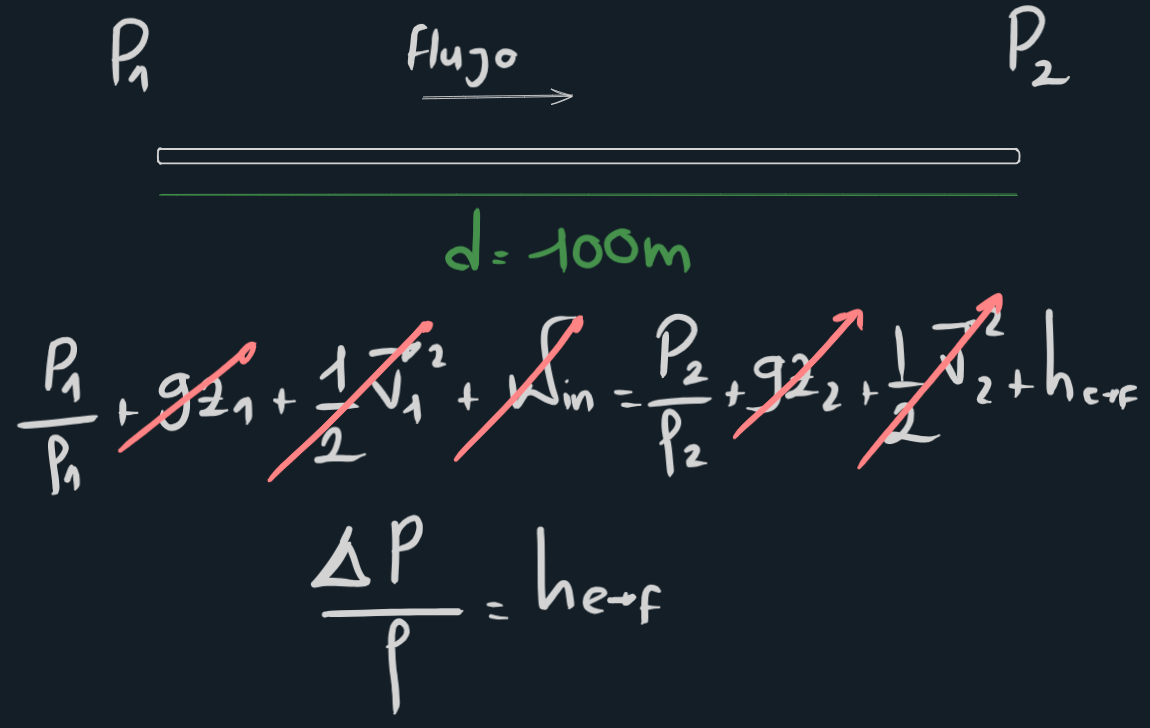

Despreciamos cambios de energía cinética, potencial, no hay inyección de trabajo externo, todo se reduce a que las perdidas de energía por flujo es igual a la energía por cambio de presión sobre densidad, si asumimos que el flujo de trabajo es agua, entonces:

In [6]:
den_agua = 1000 # kg/m³
P_1 = 1.5 
P_2 = 0.3
delta_P = (P_1 - P_2) * 101325

h_perdidas = delta_P / den_agua

print(f'Las perdidas totales deben ser: {h_perdidas:,.3f} J/kg')

Las perdidas totales deben ser: 121.590 J/kg


### 8) Se tiene una tubería donde las pérdidas mayores dadas al caudal de operación equivalen a 5mca por metro lineal de tubería. Si se dispone de una cabeza de 40 mca, calcule la longitud de tubería en la cual se puede garantizar el flujo sin necesidad de aportes energéticos adicionales.

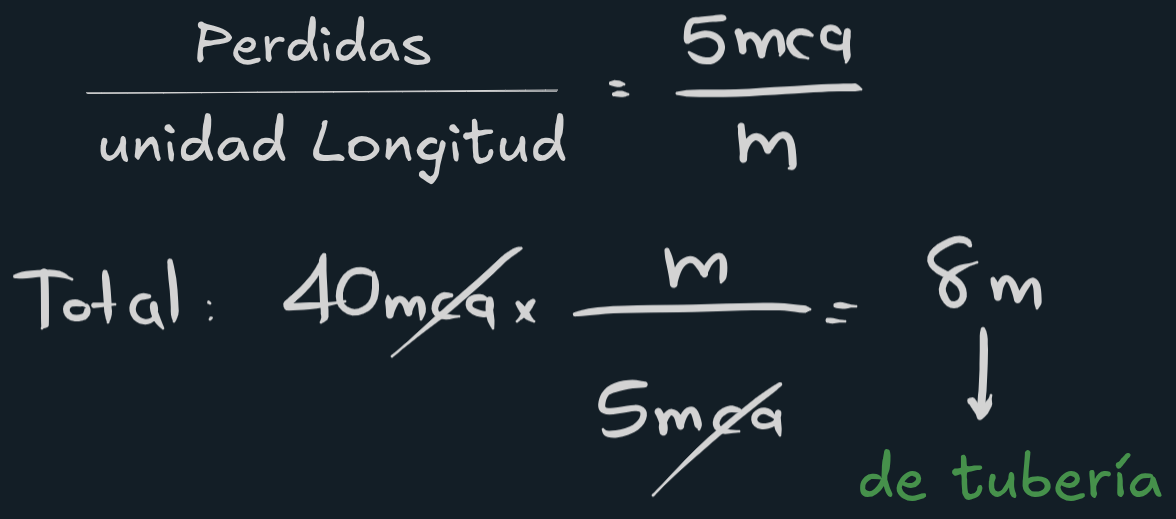

### 9) Se requiere instalar un filtro superficial de 

- 3m² de área que opera a presión constante para 
- filtrar 300l/h de un fluido de proceso, como se muestra en la figura.

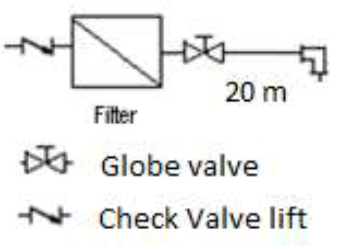

Se dispone de dos tipos de tuberías para realizar el montaje: 
- Tubería acero inoxidable 316 DN 1 inch Sch 40 (rugosidad 45 micron) 
    - accesorios roscados. 
    - el tubo de 6m cuesta 165 USD 

- Tuberia acero inoxidable 316 DN 3 inch Sch 40
    - accesorios soldados
    - el tubo de 6m cuesta 210 USD

Se requiere que la presión en el punto de descarga del sistema sea de al menos de 0.5 bar.<br>
Si se dispone de una cabeza de 3 bar a en el fluido a la entrada del sistema, comprobar si se puede realizar el transporte y filtración sin necesidad de aportes adicionales<br>

Utilizando una de las dos tuberías disponibles...
1. Calcule las pérdidas en el filtro si, gracias a datos experimentales, se sabe que el parámetro de formación de la torta uW/2k es igual a 3 bar*h/m2 
2. Calcule las pérdidas totales, (por accesorios, por longitud y por el filtro) en el montaje sugerido para cada una de las dos tuberías. (La viscosidad cinematica del fluido puede considerarla 1x10^-5 m2/s). 
3. ¿Cuál de las dos tuberías sugeriría usted para realzar el montaje? Justifique su elección por al menos dos motivos diferentes.

In [7]:
#   Análisis para Tubería acero inoxidable 316 DN 1 inch Sch 40 (rugosidad 45 micron)
print("Análisis para Tubería acero inoxidable 316 DN 1 inch Sch 40 (rugosidad 45 micron)")
# Unidades:

g = 9.8                 # gravedad m / s²
visc_cinem = 1e-05      # viscosidad cinematica m² / s
caudal = 300 * (1/1000) * (1/3600) # caudal m³ / s

#   Detalles tubería:
D_interno = 1.049 * (0.0254)        # diametro interno m
rugosidad = 45 * 1e-06              # rugodsidad m

#   Calculos :

A_flujo = np.pi * ((D_interno**2)/4)
vel_flujo = caudal / A_flujo

print(f'Area de flujo : {A_flujo:,.4f} m²')
print(f'velocidad de flujo : {vel_flujo:,.4f} m/s')


#   Objetivo 1 : Determinar reynolds para conocer el régimen de flujo:
#   ------------------------------------------------------------------

Reynolds = vel_flujo * D_interno / visc_cinem

print(f'\nNúmero de Reynolds para este régimen : {Reynolds:,.4f} ({Reynolds:,.2e})')
print(f'Al ser mayor a 4000 (Re > 4000), el flujo es turbulento')


#   Objetivo 2 : Perdidas en el filtro:
'''
    Asumimos que la resistencia del medio filtrante es mínima, por tanto, a = 0
    y C_2 = 0, y el valor del líquido filtrado es Q*t

    usamos la siguiente expresión:

    -Delta_P * t = C_1 * (Q*t/A)^2 
    
    no indican que fluido es ni la densidad, por tanto asumimos fluidos semejantes al agua en estado líquido a T ambiente
'''
#   ------------------------------------------------------------------
A_filtro = 3    # esto es de filtro m²
uW_2k = 3       
uW_2k = uW_2k * (100000) * (3600)   # se realiza la conversión a : Pa . s / m²
C_1 = uW_2k
den_fluido = 1000   # kg/m³
'''
Tenemos la siguiente expresión:

delta_P_filtro = C_1 * ((caudal)/area_filtro)**2 * t

en este caso, el valor de t ya esta implicito en C_1, ya que C_1 es un parametro global que ya incluye en tiempo para análisis experimentales
por tanto
'''

delta_P_filtro = C_1 * ((caudal)/A_filtro)**2 
h_perdidas_filtro = delta_P_filtro / den_fluido

print(f'\nCambio de presión en el filtro : {delta_P_filtro:,.10f} Pa')
print(f'Cambio de presión en el filtro : {delta_P_filtro/100000:,.10f} Bar')
print(f'Pérdidas de energía en el filtro : {h_perdidas_filtro:,.10f} J/kg\n')
print('Se asumira Pérdidas de energía en el filtro como despreciable al ser tan bajo')


#   Objetivo 3  : Perdidas de flujo desde check valve lift hasta el codo de 90°, se ignora el tramo antes del check valve lif y despues de el accesorio codo:
#   check valve lift ; filtro ; globe valve ; L_20m ; codo
#   ------------------------------------------------------------------------------------------------------------------------------------------------------

#   Sección solo tuberías (L_20m):
#   el factor de darcy solo es funcion de propiedades de flujo y area de flujo de tubería.
fd_AI_DN1_SCH40 = calculo_Fd(rugosidad, D_interno, Reynolds)
h_L_20m = (20/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN1_SCH40

#   Sección accesorios y valvulas (bomba_descarga ; valv_globo_standard ; T_ ; valv_check):
#   Para efectos prácticos, se usara el método de las 2k

k1_valv_check_lift = 2000 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_check_lift = 10  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_check_lift = calculo_k_2k(D_interno, Reynolds, k1_valv_check_lift, kinf_valv_check_lift)

k1_valv_globo_standard = 1500 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_globo_standard = 4  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_globo_standard = calculo_k_2k(D_interno, Reynolds, k1_valv_globo_standard, kinf_valv_globo_standard)

k1_codo = 800 # Tomado del catálogo de la asignatura (OPTCM) tipo rosca
kinf_codo = 0.4  # Tomado del catálogo de la asignatura (OPTCM) tipo rosca
K_codo = calculo_k_2k(D_interno, Reynolds, k1_T_, kinf_T_)

h_valv_check_lift = K_valv_check_lift * ((vel_flujo**2)/2)
h_valv_globo_standard = K_valv_globo_standard * ((vel_flujo**2)/2)
h_codo = K_codo * ((vel_flujo**2)/2)

#   Calculamos h_total:

h_total = h_valv_check_lift + h_perdidas_filtro + h_valv_globo_standard + h_L_20m + h_codo

print(f'perdidas locales total : {h_total:,.4f} J/kg')
print(f'perdidas locales total : {h_total/1000:,.6f} kJ/kg')

#   Objetivo 4: Garantizar el flujo
'''
    Aplicamos Bernoulli, y despreciando cambios de energía cínetica y potencial, tenemos:
'''
#   ---------------------------------------------------------------------------------------------------------------------------------------------------------

P_in = 3 * (100000)
P_out = 0.5 * (100000)
delta_P = P_blender - P_atm
Energia_por_presión = delta_P/den_fluido

if Energia_por_presión > h_total:
    print(f'la energía por cambio de presión ({Energia_por_presión:,.4f} Pa) es MAYOR a las perdidas por fricción ({h_total:,.4f} Pa); si hay flujo entre entrada y salida')
else:
    print(f'la energía por cambio de presión ({Energia_por_presión:,.4f} Pa) es MENOR a las perdidas por fricción ({h_total:,.4f} Pa); si hay flujo entre entrada y salida')

Análisis para Tubería acero inoxidable 316 DN 1 inch Sch 40 (rugosidad 45 micron)
Area de flujo : 0.0006 m²
velocidad de flujo : 0.1495 m/s

Número de Reynolds para este régimen : 398.2169 (3.98e+02)
Al ser mayor a 4000 (Re > 4000), el flujo es turbulento

Cambio de presión en el filtro : 0.8333333333 Pa
Cambio de presión en el filtro : 0.0000083333 Bar
Pérdidas de energía en el filtro : 0.0008333333 J/kg

Se asumira Pérdidas de energía en el filtro como despreciable al ser tan bajo
perdidas locales total : 1.1106 J/kg
perdidas locales total : 0.001111 kJ/kg
la energía por cambio de presión (28.6750 Pa) es MAYOR a las perdidas por fricción (1.1106 Pa); si hay flujo entre entrada y salida


In [8]:
#   Análisis para Tuberia acero inoxidable 316 DN 3 inch Sch 40 (rugosidad 45 micron)
print("Análisis para Tuberia acero inoxidable 316 DN 3 inch Sch 40 (rugosidad 45 micron)")
# Unidades:

g = 9.8                 # gravedad m / s²
visc_cinem = 1e-05      # viscosidad cinematica m² / s
caudal = 300 * (1/1000) * (1/3600) # caudal m³ / s

#   Detalles tubería:
D_interno = 3.068 * (0.0254)        # diametro interno m
rugosidad = 45 * 1e-06              # rugodsidad m

#   Calculos :

A_flujo = np.pi * ((D_interno**2)/4)
vel_flujo = caudal / A_flujo

print(f'Area de flujo : {A_flujo:,.4f} m²')
print(f'velocidad de flujo : {vel_flujo:,.4f} m/s')


#   Objetivo 1 : Determinar reynolds para conocer el régimen de flujo:
#   ------------------------------------------------------------------

Reynolds = vel_flujo * D_interno / visc_cinem

print(f'\nNúmero de Reynolds para este régimen : {Reynolds:,.4f} ({Reynolds:,.2e})')
print(f'Al ser mayor a 4000 (Re > 4000), el flujo es turbulento')


#   Objetivo 2 : Perdidas en el filtro:
'''
    Asumimos que la resistencia del medio filtrante es mínima, por tanto, a = 0
    y C_2 = 0, y el valor del líquido filtrado es Q*t

    usamos la siguiente expresión:

    -Delta_P * t = C_1 * (Q*t/A)^2 
    
    no indican que fluido es ni la densidad, por tanto asumimos fluidos semejantes al agua en estado líquido a T ambiente
'''
#   ------------------------------------------------------------------
A_filtro = 3    # esto es de filtro m²
uW_2k = 3       
uW_2k = uW_2k * (100000) * (3600)   # se realiza la conversión a : Pa . s / m²
C_1 = uW_2k
den_fluido = 1000   # kg/m³
'''
Tenemos la siguiente expresión:

delta_P_filtro = C_1 * ((caudal)/area_filtro)**2 * t

en este caso, el valor de t ya esta implicito en C_1, ya que C_1 es un parametro global que ya incluye en tiempo para análisis experimentales
por tanto
'''

delta_P_filtro = C_1 * ((caudal)/A_filtro)**2 
h_perdidas_filtro = delta_P_filtro / den_fluido

print(f'\nCambio de presión en el filtro : {delta_P_filtro:,.10f} Pa')
print(f'Cambio de presión en el filtro : {delta_P_filtro/100000:,.10f} Bar')
print(f'Pérdidas de energía en el filtro : {h_perdidas_filtro:,.10f} J/kg\n')
print('Se asumira Pérdidas de energía en el filtro como despreciable al ser tan bajo')


#   Objetivo 3  : Perdidas de flujo desde check valve lift hasta el codo de 90°, se ignora el tramo antes del check valve lif y despues de el accesorio codo:
#   check valve lift ; filtro ; globe valve ; L_20m ; codo
#   ------------------------------------------------------------------------------------------------------------------------------------------------------

#   Sección solo tuberías (L_20m):
#   el factor de darcy solo es funcion de propiedades de flujo y area de flujo de tubería.
fd_AI_DN3_SCH40 = calculo_Fd(rugosidad, D_interno, Reynolds)
h_L_20m = (20/D_interno) * ((vel_flujo**2)/2) * fd_AI_DN3_SCH40

#   Sección accesorios y valvulas (bomba_descarga ; valv_globo_standard ; T_ ; valv_check):
#   Para efectos prácticos, se usara el método de las 2k

k1_valv_check_lift = 2000 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_check_lift = 10  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_check_lift = calculo_k_2k(D_interno, Reynolds, k1_valv_check_lift, kinf_valv_check_lift)

k1_valv_globo_standard = 1500 # Tomado del catálogo de la asignatura (OPTCM)
kinf_valv_globo_standard = 4  # Tomado del catálogo de la asignatura (OPTCM)
K_valv_globo_standard = calculo_k_2k(D_interno, Reynolds, k1_valv_globo_standard, kinf_valv_globo_standard)

k1_codo = 800 # Tomado del catálogo de la asignatura (OPTCM) tipo soldado
kinf_codo = 0.25  # Tomado del catálogo de la asignatura (OPTCM) tipo soldadp
K_codo = calculo_k_2k(D_interno, Reynolds, k1_T_, kinf_T_)

h_valv_check_lift = K_valv_check_lift * ((vel_flujo**2)/2)
h_valv_globo_standard = K_valv_globo_standard * ((vel_flujo**2)/2)
h_codo = K_codo * ((vel_flujo**2)/2)

#   Calculamos h_total:

h_total = h_valv_check_lift + h_perdidas_filtro + h_valv_globo_standard + h_L_20m + h_codo

print(f'perdidas locales total : {h_total:,.4f} J/kg')
print(f'perdidas locales total : {h_total/1000:,.6f} kJ/kg')

#   Objetivo 4: Garantizar el flujo
'''
    Aplicamos Bernoulli, y despreciando cambios de energía cínetica y potencial, tenemos:
'''
#   ---------------------------------------------------------------------------------------------------------------------------------------------------------

P_in = 3 * (100000)
P_out = 0.5 * (100000)
delta_P = P_blender - P_atm
Energia_por_presión = delta_P/den_fluido

if Energia_por_presión > h_total:
    print(f'la energía por cambio de presión ({Energia_por_presión:,.4f} Pa) es MAYOR a las perdidas por fricción ({h_total:,.4f} Pa); si hay flujo entre entrada y salida')
else:
    print(f'la energía por cambio de presión ({Energia_por_presión:,.4f} Pa) es MENOR a las perdidas por fricción ({h_total:,.4f} Pa); si hay flujo entre entrada y salida')


Análisis para Tuberia acero inoxidable 316 DN 3 inch Sch 40 (rugosidad 45 micron)
Area de flujo : 0.0048 m²
velocidad de flujo : 0.0175 m/s

Número de Reynolds para este régimen : 136.1569 (1.36e+02)
Al ser mayor a 4000 (Re > 4000), el flujo es turbulento

Cambio de presión en el filtro : 0.8333333333 Pa
Cambio de presión en el filtro : 0.0000083333 Bar
Pérdidas de energía en el filtro : 0.0008333333 J/kg

Se asumira Pérdidas de energía en el filtro como despreciable al ser tan bajo
perdidas locales total : 0.0125 J/kg
perdidas locales total : 0.000013 kJ/kg
la energía por cambio de presión (28.6750 Pa) es MAYOR a las perdidas por fricción (0.0125 Pa); si hay flujo entre entrada y salida


# Conclusión ejercicio anterior:

- Análisis para Tubería acero inoxidable 316 DN 1 inch Sch 40 (rugosidad 45 micron)
las perdidas por fricción (1.1106 Pa); si hay flujo entre entrada y salida

- Análisis para Tuberia acero inoxidable 316 DN 3 inch Sch 40 (rugosidad 45 micron)
las perdidas por fricción (0.0125 Pa); si hay flujo entre entrada y salida

---

- Se requieren comprar 4 tuberías de 6m de cada tipo de tubería propuestas. El de diametro nominal 3 claramente es mas costoso, así que esta es la primera razón que optamos por seleccionar la tubería de DN 1, ambas garantizar el flujo entres los dos puntos de flujo.

- Adecuar accesorio tipo rosca tambien es de facil mantenimiento que soldadura, y evidentemente, el tipo de forma en la que se incorporan accesorios a las tuberías no impacta mucho en las perdidas de energía para el flujo
